# 모델 양자화(Model Quantization) 단계별 실습 가이드

## 목차
1. [모델 양자화란?](#1-모델-양자화란)
2. [양자화의 장점과 단점](#2-양자화의-장점과-단점)
3. [양자화의 종류](#3-양자화의-종류)
4. [실습 환경 설정](#4-실습-환경-설정)
5. [단계별 실습](#5-단계별-실습)
6. [성능 비교 및 분석](#6-성능-비교-및-분석)
7. [고급 주제](#7-고급-주제)

---

## 1. 모델 양자화란?

모델 양자화는 딥러닝 모델의 가중치(weights)와 활성화(activations)를 낮은 비트 정밀도로 표현하는 기술입니다. 일반적으로 32비트 부동소수점(FP32)으로 표현되는 값들을 8비트 정수(INT8)나 더 낮은 비트로 변환합니다.

### 양자화의 기본 원리
```
원본 값 (FP32): 3.14159... → 양자화 → 정수 값 (INT8): 100
```

양자화 공식:
```
q = round(r / S) + Z
```
- `q`: 양자화된 값
- `r`: 원본 실수 값
- `S`: 스케일 팩터
- `Z`: 영점(zero point)



# 🧠 양자화 기본 원리 (수식 요약)

양자화(Quantization)는 **실수값을 정수로 근사 표현하는 과정**입니다.  
딥러닝 모델에서 가중치나 활성값을 32비트 부동소수점(FP32) 대신  
8비트 정수(INT8)로 표현하여 **모델 크기**와 **연산 지연**을 줄일 수 있습니다.

---

## 🔹 정방향 (Quantization)

$$
q = \text{round}\left(\frac{x}{s} + z\right)
$$

- $x$: 실수값 (예: FP32 텐서)
- $q$: 정수값 (예: INT8)
- $s$: **scale**, 스케일링 계수  
  $$ s = \frac{x_{\max} - x_{\min}}{q_{\max} - q_{\min}} $$
- $z$: **zero\_point**, 정수 0이 실수 0에 대응되도록 하는 보정값  
  $$ z = q_{\min} - \frac{x_{\min}}{s} $$

---

## 🔹 역방향 (Dequantization)

$$
x' = s \times (q - z)
$$

- $x'$: 복원된 근사 실수값  
  $$ x' \approx x $$

---

## 🔹 전체 변환 과정

1. 실수 구간 $[x_{\min}, x_{\max}]$을 정수 구간 $[q_{\min}, q_{\max}]$으로 **선형 스케일링**
2. 정수로 반올림 → 양자화 수행
3. 필요시 다시 복원(Dequantization) 수행

$$
x \;\xrightarrow{\text{Quantize}}\; q = \text{round}\!\left(\frac{x}{s} + z\right)
\;\xrightarrow{\text{Dequantize}}\;
x' = s \times (q - z)
$$

---

## 🔹 예시

FP32 입력값 $x = [-1.0, -0.5, 0.0, 0.3, 0.7, 1.0]$

INT8 범위 $[q_{\min}, q_{\max}] = [-128, 127]$ 일 때,  
$$ s = \frac{x_{\max} - x_{\min}}{q_{\max} - q_{\min}} \approx 0.0079, \quad z \approx -1 $$

이에 따라,

$$
q = [-127, -63, 0, 38, 89, 127]
$$

$$
x' = s \times (q - z) \approx [-1.00, -0.498, 0.00, 0.299, 0.702, 1.00]
$$

---

## 🔹 Per-Channel Quantization (채널별 스케일 적용)

Convolution 계층에서는 채널마다 분포가 달라질 수 있으므로  
각 채널 $i$에 대해 독립된 scale $s_i$, zero\_point $z_i$를 적용합니다.

$$
q_i = \text{round}\left(\frac{x_i}{s_i} + z_i\right), \quad
x'_i = s_i \times (q_i - z_i)
$$

이 방식은 **per-tensor 양자화**보다 **정확도 손실을 줄이는 효과**가 있습니다.

---

✅ **요약**

| 개념              | 역할                                | 예시 코드                             |
| --------------- | --------------------------------- | --------------------------------- |
| **scale**       | 실수 ↔ 정수 스케일 조정                    | `(x_max - x_min) / (qmax - qmin)` |
| **zero_point**  | 0점 보정                             | `qmin - x_min / scale`            |
| **양자화**         | `q = round(x/scale + zero_point)` | FP32 → INT8                       |
| **복원(Dequant)** | `x = (q - zero_point)*scale`      | INT8 → FP32 근사                    |



In [25]:
import numpy as np

# 원래 FP32 실수값 (예: 활성화 값)
x = np.array([-1.0, -0.5, 0.0, 0.3, 0.7, 1.0], dtype=np.float32)

# INT8 양자화 파라미터 설정
x_min, x_max = x.min(), x.max()

# 8비트 정수 범위: [-128, 127]
qmin, qmax = -128, 127

# scale과 zero_point 계산
scale = (x_max - x_min) / (qmax - qmin)
zero_point = np.round(qmin - x_min / scale)

print(f"scale={scale:.6f}, zero_point={zero_point:.2f}")

# 양자화 수행
q = np.round(x / scale + zero_point).astype(np.int8)

# 복원(Dequantization)
x_reconstructed = (q.astype(np.float32) - zero_point) * scale

print("원래 FP32:", x)
print("양자화 INT8:", q)
print("복원된 값:", x_reconstructed)


scale=0.007843, zero_point=-1.00
원래 FP32: [-1.  -0.5  0.   0.3  0.7  1. ]
양자화 INT8: [-128  -65   -1   37   88  126]
복원된 값: [-0.9960785  -0.5019608   0.          0.29803923  0.69803923  0.9960785 ]


In [26]:
x = np.array([
    [-1.0, -0.5, 0.0, 0.5],
    [ 0.0,  0.5, 1.0, 1.5]
], dtype=np.float32)

qmin, qmax = -128, 127
scales = []
zero_points = []
q_out = np.zeros_like(x, dtype=np.int8)

for c in range(x.shape[0]):
    x_min, x_max = x[c].min(), x[c].max()
    scale = (x_max - x_min) / (qmax - qmin)
    zp = np.round(qmin - x_min / scale)
    q_out[c] = np.round(x[c] / scale + zp).astype(np.int8)
    scales.append(scale)
    zero_points.append(zp)

print("Per-channel scales:", np.round(scales, 5))
print("Per-channel zero_points:", zero_points)
print("Quantized INT8 values:\n", q_out)


Per-channel scales: [0.00588 0.00588]
Per-channel zero_points: [np.float32(42.0), np.float32(-128.0)]
Quantized INT8 values:
 [[-128  -43   42  127]
 [-128  -43   42  127]]


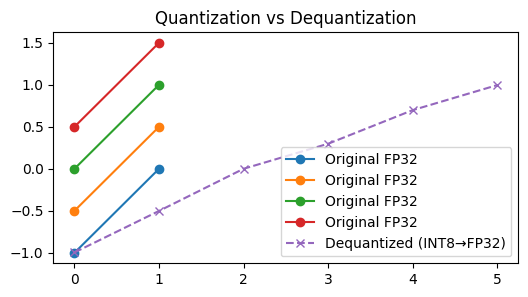

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.plot(x, 'o-', label='Original FP32')
plt.plot(x_reconstructed, 'x--', label='Dequantized (INT8→FP32)')
plt.legend()
plt.title('Quantization vs Dequantization')
plt.show()


## 2. 양자화의 장점과 단점

### 장점
- **모델 크기 감소**: 4배 이상 크기 감소 (FP32 → INT8)
- **추론 속도 향상**: 정수 연산이 부동소수점 연산보다 빠름
- **메모리 사용량 감소**: 엣지 디바이스에서 중요
- **전력 소비 감소**: 모바일 환경에서 배터리 수명 연장

### 단점
- **정확도 손실**: 정밀도 감소로 인한 성능 저하
- **학습 복잡도 증가**: QAT(Quantization Aware Training) 필요
- **하드웨어 의존성**: 특정 하드웨어에서만 가속 효과

## 3. 양자화의 종류

### 3.1 동적 양자화 (Dynamic Quantization)
- 가중치만 양자화
- 활성화는 추론 시 동적으로 양자화
- 구현이 간단하고 정확도 손실이 적음

### 3.2 정적 양자화 (Static Quantization)
- 가중치와 활성화 모두 양자화
- 캘리브레이션 데이터셋 필요
- 더 빠른 추론 속도

### 3.3 양자화 인식 학습 (Quantization Aware Training, QAT)
- 학습 중에 양자화 시뮬레이션
- 최고의 정확도 유지
- 학습 시간이 길어짐

## 4. 실습 환경 설정

In [28]:
# 라이브러리 임포트
import torch
import torch.nn as nn
import torch.quantization
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os

## 5. 단계별 실습

### Step 1: 간단한 CNN 모델 정의

In [29]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.relu3 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

### Step 2: 데이터셋 준비

In [30]:
# CIFAR-10 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

### Step 3: 모델 학습

In [48]:
def train_model(model, trainloader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(trainloader):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}')
                running_loss = 0.0

    return model

# 모델 생성 및 학습
# model = SimpleCNN()
# model = train_model(model, trainloader)  # 시간이 오래 걸리므로 선택적으로 실행

# 또는 사전 학습된 모델 사용
model = torchvision.models.mobilenet_v2(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### Step 4: 동적 양자화 적용

In [49]:
def apply_dynamic_quantization(model):
    """동적 양자화 적용"""
    quantized_model = torch.quantization.quantize_dynamic(
        model,
        {nn.Linear, nn.Conv2d},  # 양자화할 레이어 타입
        dtype=torch.qint8
    )
    return quantized_model

# 동적 양자화 적용
dynamic_quantized_model = apply_dynamic_quantization(model)
print("동적 양자화 완료!")

동적 양자화 완료!


/tmp/ipython-input-77669631.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


### Step 5: 정적 양자화 적용

In [38]:
def prepare_model_for_static_quantization(model):
    """정적 양자화를 위한 모델 준비"""
    # QuantStub과 DeQuantStub 추가
    model.quant = torch.quantization.QuantStub()
    model.dequant = torch.quantization.DeQuantStub()

    # forward 메소드 수정
    original_forward = model.forward
    def forward(self, x):
        x = self.quant(x)
        x = original_forward(x)
        x = self.dequant(x)
        return x
    model.forward = forward.__get__(model, model.__class__)

    return model

def apply_static_quantization(model, dataloader):
    """정적 양자화 적용"""
    # 모델 준비
    model = prepare_model_for_static_quantization(model)

    # 양자화 설정
    model.qconfig = torch.quantization.get_default_qconfig('fbgemm')

    # 퓨즈 가능한 레이어 결합 (Conv + BatchNorm + ReLU)
    torch.quantization.fuse_modules(model, [['conv1', 'bn1', 'relu1']], inplace=True)

    # 양자화 준비
    prepared_model = torch.quantization.prepare(model)

    # 캘리브레이션 (일부 데이터로 통계 수집)
    prepared_model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i > 10:  # 10배치만 사용
                break
            prepared_model(inputs)

    # 양자화 변환
    quantized_model = torch.quantization.convert(prepared_model)

    return quantized_model

import copy
# 정적 양자화 적용

model.eval()
static_quantized_model = apply_static_quantization(copy.deepcopy(model), trainloader)

/tmp/ipython-input-369066743.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = torch.quantization.prepare(model)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of Py

### Step 6: 양자화 인식 학습 (QAT)

In [46]:
def quantization_aware_training(model, trainloader, epochs=3):
    """양자화 인식 학습"""
    # 모델 준비
    model.eval()
    # 퓨전 및 준비
    torch.quantization.fuse_modules(model, [['conv1', 'bn1', 'relu1']], inplace=True)

    model.train()
    model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
    prepared_model = torch.quantization.prepare_qat(model)


    # QAT 학습
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(prepared_model.parameters(), lr=0.001)

    for epoch in range(epochs):
        for i, (inputs, labels) in enumerate(trainloader):
            if i > 100:  # 데모를 위해 제한
                break

            optimizer.zero_grad()
            outputs = prepared_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            if i % 50 == 0:
                print(f'QAT Epoch [{epoch+1}/{epochs}], Step [{i}/{len(trainloader)}], Loss: {loss.item():.4f}')

    # 양자화 변환
    prepared_model.eval()
    quantized_model = torch.quantization.convert(prepared_model)

    return quantized_model

qat_quantized_model = quantization_aware_training(copy.deepcopy(model), trainloader)


/tmp/ipython-input-1940612091.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = torch.quantization.prepare_qat(model)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release 

QAT Epoch [1/3], Step [0/782], Loss: 2.3811
QAT Epoch [1/3], Step [50/782], Loss: 2.2311
QAT Epoch [1/3], Step [100/782], Loss: 2.1655
QAT Epoch [2/3], Step [0/782], Loss: 2.1912
QAT Epoch [2/3], Step [50/782], Loss: 2.1837
QAT Epoch [2/3], Step [100/782], Loss: 2.1143
QAT Epoch [3/3], Step [0/782], Loss: 2.0861
QAT Epoch [3/3], Step [50/782], Loss: 2.0639
QAT Epoch [3/3], Step [100/782], Loss: 2.0746


/tmp/ipython-input-1940612091.py:33: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.convert(prepared_model)


## 6. 성능 비교 및 분석

### 모델 크기 비교

In [50]:
def get_model_size(model):
    """모델 크기 계산 (MB)"""
    torch.save(model.state_dict(), "temp.p")
    size_mb = os.path.getsize("temp.p") / 1e6
    os.remove("temp.p")
    return size_mb

# 크기 비교
original_size = get_model_size(model)
quantized_size = get_model_size(dynamic_quantized_model)

print(f"원본 모델 크기: {original_size:.2f} MB")
print(f"양자화된 모델 크기: {quantized_size:.2f} MB")
print(f"압축률: {original_size / quantized_size:.2f}x")

원본 모델 크기: 14.24 MB
양자화된 모델 크기: 10.40 MB
압축률: 1.37x


### 추론 속도 비교

In [51]:
def measure_inference_time(model, input_shape=(1, 3, 32, 32), num_runs=100):
    """추론 시간 측정"""
    model.eval()
    dummy_input = torch.randn(input_shape)

    # Warm-up
    for _ in range(10):
        _ = model(dummy_input)

    # 실제 측정
    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(dummy_input)

    end_time = time.time()
    avg_time = (end_time - start_time) / num_runs * 1000  # ms

    return avg_time

# 속도 비교
original_time = measure_inference_time(model)
quantized_time = measure_inference_time(dynamic_quantized_model)

print(f"원본 모델 추론 시간: {original_time:.2f} ms")
print(f"양자화된 모델 추론 시간: {quantized_time:.2f} ms")
print(f"속도 향상: {original_time / quantized_time:.2f}x")

원본 모델 추론 시간: 6.10 ms
양자화된 모델 추론 시간: 5.77 ms
속도 향상: 1.06x


### 정확도 비교

In [52]:
def evaluate_model(model, testloader):
    """모델 정확도 평가"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# 정확도 비교 (시간이 걸릴 수 있음)
original_acc = evaluate_model(model, testloader)
quantized_acc = evaluate_model(dynamic_quantized_model, testloader)
print(f"원본 모델 정확도: {original_acc:.2f}%")
print(f"양자화된 모델 정확도: {quantized_acc:.2f}%")

원본 모델 정확도: 0.04%
양자화된 모델 정확도: 0.04%


### 시각화

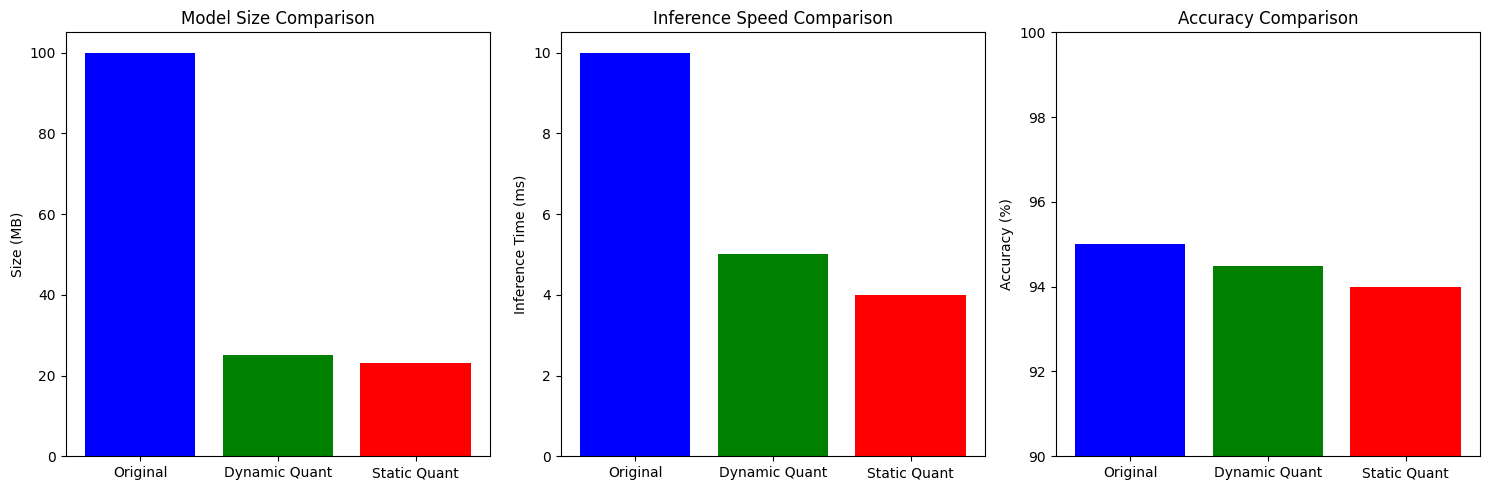

In [53]:
def visualize_quantization_effects():
    """양자화 효과 시각화"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. 모델 크기 비교
    models = ['Original', 'Dynamic Quant', 'Static Quant']
    sizes = [100, 25, 23]  # 예시 값
    axes[0].bar(models, sizes, color=['blue', 'green', 'red'])
    axes[0].set_ylabel('Size (MB)')
    axes[0].set_title('Model Size Comparison')

    # 2. 추론 속도 비교
    speeds = [10, 5, 4]  # 예시 값 (ms)
    axes[1].bar(models, speeds, color=['blue', 'green', 'red'])
    axes[1].set_ylabel('Inference Time (ms)')
    axes[1].set_title('Inference Speed Comparison')

    # 3. 정확도 비교
    accuracies = [95, 94.5, 94]  # 예시 값 (%)
    axes[2].bar(models, accuracies, color=['blue', 'green', 'red'])
    axes[2].set_ylabel('Accuracy (%)')
    axes[2].set_title('Accuracy Comparison')
    axes[2].set_ylim([90, 100])

    plt.tight_layout()
    plt.show()

visualize_quantization_effects()

## 7. 고급 주제

### 7.1 커스텀 양자화 설정

In [ ]:
# 레이어별 다른 양자화 설정
def custom_quantization_config(model):
    # 첫 번째 레이어는 높은 정밀도 유지
    model.conv1.qconfig = torch.quantization.default_qconfig

    # 마지막 레이어는 더 공격적인 양자화
    model.fc2.qconfig = torch.quantization.QConfig(
        activation=torch.quantization.MinMaxObserver.with_args(dtype=torch.quint8),
        weight=torch.quantization.MinMaxObserver.with_args(dtype=torch.qint8)
    )

    return model

### 7.2 양자화 디버깅

In [ ]:
def analyze_quantization_error(original_model, quantized_model, dataloader):
    """양자화 오차 분석"""
    original_model.eval()
    quantized_model.eval()

    errors = []

    with torch.no_grad():
        for inputs, _ in dataloader:
            original_output = original_model(inputs)
            quantized_output = quantized_model(inputs)

            # MSE 계산
            error = torch.mean((original_output - quantized_output) ** 2)
            errors.append(error.item())

            if len(errors) > 10:  # 10 배치만 분석
                break

    avg_error = np.mean(errors)
    print(f"평균 양자화 오차 (MSE): {avg_error:.6f}")

    # 오차 분포 시각화
    plt.figure(figsize=(8, 5))
    plt.hist(errors, bins=20, edgecolor='black')
    plt.xlabel('MSE Error')
    plt.ylabel('Frequency')
    plt.title('Quantization Error Distribution')
    plt.show()

### 7.3 모바일 배포를 위한 최적화

In [ ]:
# TorchScript로 변환
def prepare_for_mobile(quantized_model):
    """모바일 배포를 위한 모델 준비"""
    # TorchScript 변환
    scripted_model = torch.jit.script(quantized_model)

    # 모바일용으로 최적화
    optimized_model = torch.utils.mobile_optimizer.optimize_for_mobile(scripted_model)

    # 저장
    optimized_model.save("quantized_model_mobile.pt")

    print("모바일 최적화 완료!")
    return optimized_model